# Reaction Barrier Subsets

# Thermochemistry Subsets


FIG. 2(a) — Thermochemistry


C:\Users\91988\AppData\Local\Temp\ipykernel_7624\3426562835.py:409: RuntimeWarning: invalid value encountered in scalar divide
  (


,wB97M-V,MACE-POLAR-1-S,MACE-POLAR-1-M,MACE-POLAR-1-L,MACE-OMOL-0-100M,MACE-OMOL-0-4M,MACE-MP-0b3
Thermochemistry Subset,,,,,,,
Ionization Potentials,3.872,10.150,9.375,9.561,26.055,51.022,NaN
Electron Affinities,1.702,7.434,4.907,5.995,8.254,11.883,34.922
Proton Affinities,1.503,4.047,2.342,2.109,11.029,24.801,87.833
Mindless Molecules (MB08/16),6.120,13.093,13.662,9.414,8.666,15.372,36.587
Bond Dissociation Energies,2.157,3.445,2.655,3.010,2.935,7.881,15.112
Radical Stabilization,0.787,1.335,0.807,0.632,4.970,4.521,8.099



FIG. 2(b) — Reaction Barriers


,wB97M-V,MACE-POLAR-1-S,MACE-POLAR-1-M,MACE-POLAR-1-L,MACE-OMOL-0-100M,MACE-OMOL-0-4M,MACE-MP-0b3
Reaction Barrier Subset,,,,,,,
Barrier Heights,1.391,5.010,2.243,1.851,2.071,3.509,14.191
Proton Transfer,1.311,3.746,2.491,1.843,2.183,3.935,14.399
General Reaction Energies,0.976,2.063,1.422,1.507,1.967,4.384,14.505



Excluded points by model


exclusion_type,outlier_gt_100,single_atom,Total_excluded
Model,,,
MACE-MP-0b3,160,782,942
MACE-OMOL-0-100M,52,782,834
MACE-OMOL-0-4M,55,782,837
MACE-POLAR-1-L,1,782,783
MACE-POLAR-1-M,3,782,785
MACE-POLAR-1-S,2,782,784
wB97M-V,0,782,782



Excluded identifiers


,Identifier,Dataset,Subset,Source_Datatype,Model,Reference,Prediction,DeltaE,Abs_DeltaE,exclusion_type
0,BH76_10,BH46,Barrier Heights,Barrier Height,MACE-MP-0b3,104.800079,74.232245,-30.567834,30.567834,single_atom
1,BH76_13,BH46,Barrier Heights,Barrier Height,MACE-MP-0b3,-0.600001,-35.684195,-35.084195,35.084195,single_atom
2,BH76_17,BH46,Barrier Heights,Barrier Height,MACE-MP-0b3,2.500002,-7.539612,-10.039615,10.039615,single_atom
3,BH76_21,BH46,Barrier Heights,Barrier Height,MACE-MP-0b3,-12.300009,-33.231060,-20.931051,20.931051,single_atom
4,BH76_22,BH46,Barrier Heights,Barrier Height,MACE-MP-0b3,19.800015,-8.276085,-28.076100,28.076100,single_atom
...,...,...,...,...,...,...,...,...,...,...
5742,PA26_7,PA26,Proton Affinities,Thermochemistry,MACE-OMOL-0-100M,157.400119,278.737077,121.336958,121.336958,outlier_gt_100
5743,PA26_1,PA26,Proton Affinities,Thermochemistry,MACE-OMOL-0-4M,167.200127,292.975962,125.775836,125.775836,outlier_gt_100
5744,PA26_12,PA26,Proton Affinities,Thermochemistry,MACE-OMOL-0-4M,106.200081,277.666588,171.466507,171.466507,outlier_gt_100
5745,PA26_13,PA26,Proton Affinities,Thermochemistry,MACE-OMOL-0-4M,120.800091,222.227386,101.427294,101.427294,outlier_gt_100


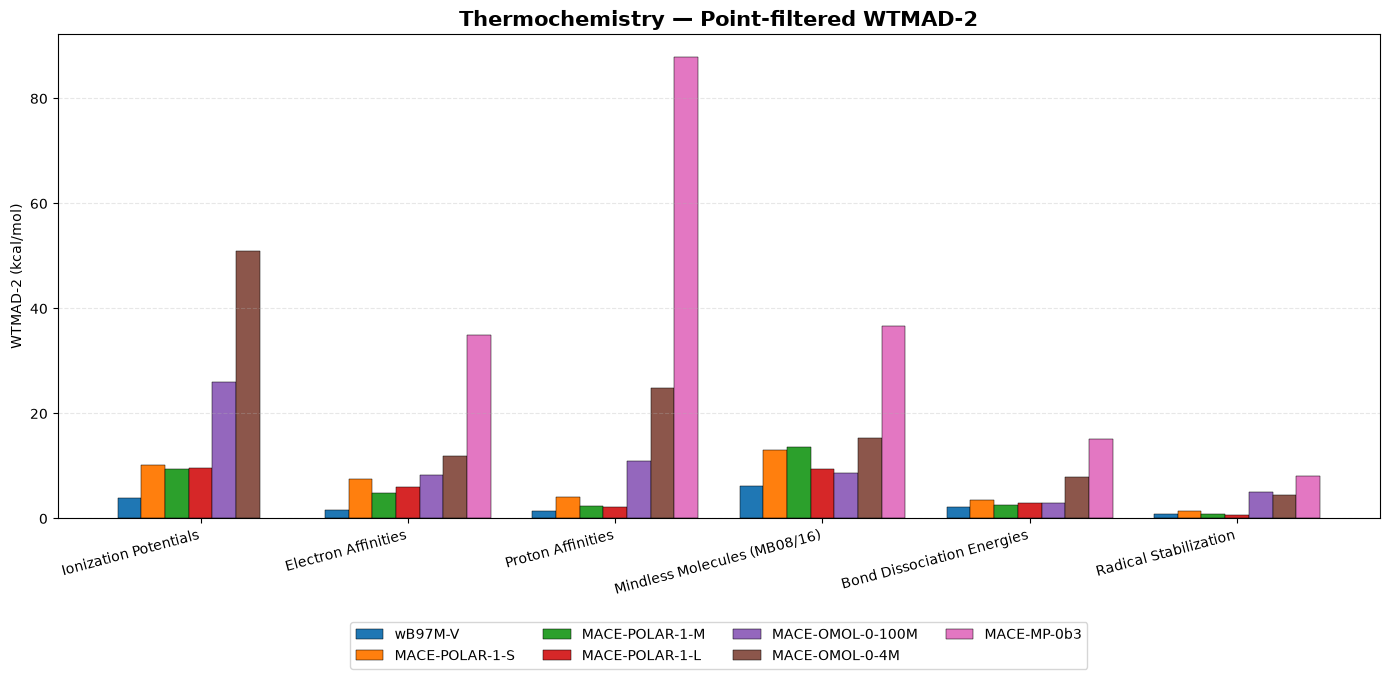

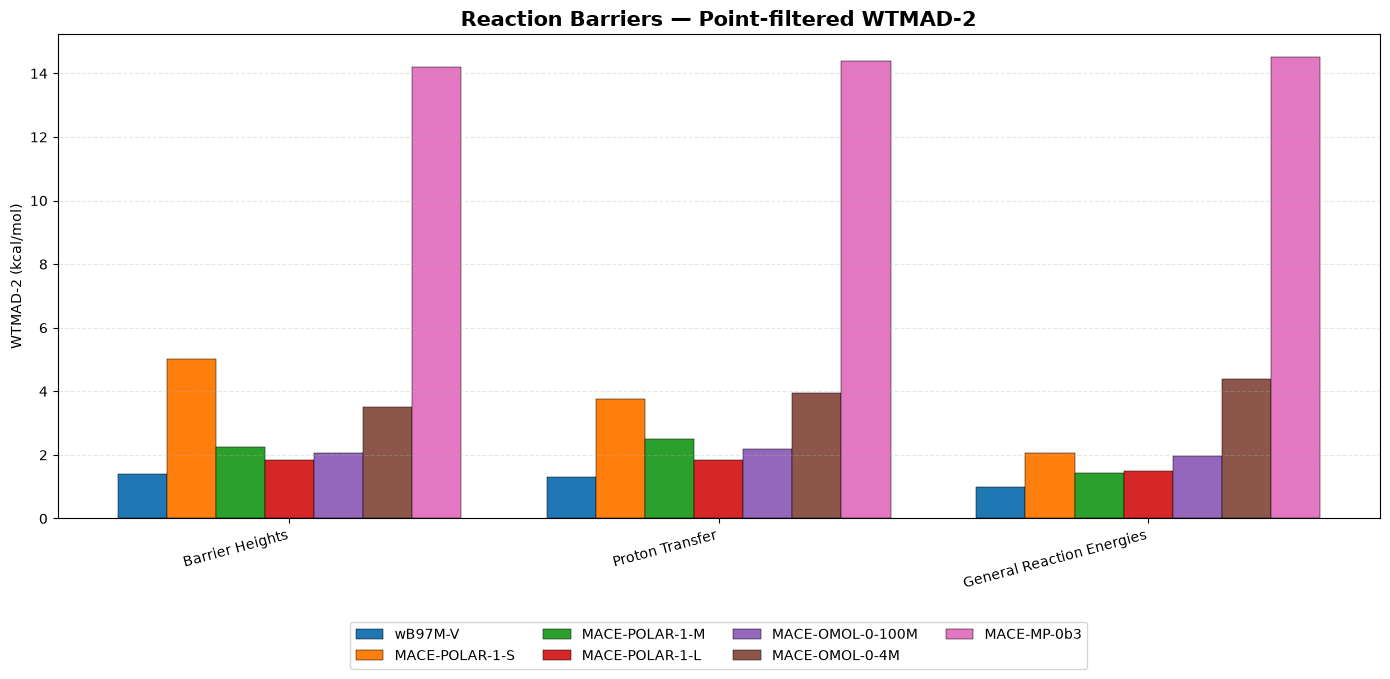

In [1]:
# ================================================================
# FIG. 2(a,b) — POINT-LEVEL FILTERED WTMAD-2
# Thermochemistry + Reaction Barrier subsets
#
# Uses the exact point-level CSV files already present in Analysis/
#
# Exclusions BEFORE per-dataset MAE:
#   1. single-atom configurations
#   2. missing/evaluation-failed predictions
#   3. |Prediction - Reference| > 100 kcal/mol
#
# Also saves complete lists of excluded identifiers.
# ================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CUTOFF = 100.0
REMOVE_SINGLE_ATOM = True

ROOT = Path.cwd().parent if Path.cwd().name == "Analysis" else Path.cwd()
A, I, X = ROOT/"Analysis", ROOT/"Info", ROOT/"xyz_files"

MODELS = [
    "wB97M-V",
    "MACE-POLAR-1-S",
    "MACE-POLAR-1-M",
    "MACE-POLAR-1-L",
    "MACE-OMOL-0-100M",
    "MACE-OMOL-0-4M",
    "MACE-MP-0b3"
]

# ================================================================
# 1. Exact Fig. 2 subset definitions from MACE-POLAR SI
# ================================================================

THERMO_GROUPS = {
    "Ionization Potentials":
        ["G21IP", "IP23", "IP30"],

    "Electron Affinities":
        ["G21EA", "EA50"],

    "Proton Affinities":
        ["PA26"],

    "Mindless Molecules (MB08/16)":
        ["MB08-165", "MB16-43"],

    "Bond Dissociation Energies":
        ["BDE99MR", "BDE99nonMR",
         "HNBrBDE18", "YBDE18",
         "HAT707MR", "HAT707nonMR",
         "BSR36"],

    "Radical Stabilization":
        ["RSE43"]
}

BARRIER_GROUPS = {
    "Barrier Heights":
        ["BH28", "BH46", "BH876",
         "BHDIV7", "ORBH35", "CRBH14"],

    "Proton Transfer":
        ["DBH22", "PX9", "WCPT26"],

    "General Reaction Energies":
        ["FH51", "G2RC24", "BH76RC",
         "CR20", "DARC", "NBPRC", "RC21"]
}

ALL_GROUPS = {**THERMO_GROUPS, **BARRIER_GROUPS}

THERMO_SETS = sum(THERMO_GROUPS.values(), [])
BARRIER_SETS = sum(BARRIER_GROUPS.values(), [])
ALL_SETS = list(dict.fromkeys(THERMO_SETS + BARRIER_SETS))

GROUP_OF = {
    dataset: group
    for group, datasets in ALL_GROUPS.items()
    for dataset in datasets
}

# ================================================================
# 2. Load exact point-level files from your repository
# ================================================================

# ---------------- Barrier Height ----------------

bh_polar = pd.read_csv(
    A/"Results_values_with_MACE_POLAR_Datatype_Barrier_Height_ALL3.csv"
)

bh_omol = pd.read_csv(
    A/"Results_values_with_MACE_OMOL0_Datatype_Barrier_ Height.csv"
)

bh_mp = pd.read_csv(
    A/"Reaction_Energies_MACE_MP_0b3_Barrier_Height.csv"
)

# ---------------- Thermochemistry ----------------

tc_polar = pd.read_csv(
    A/"Results_values_with_MACE_POLAR_Datatype_Thermochemistry_ALL3.csv"
)

tc_omol = pd.read_csv(
    A/"Results_values_with_MACE_OMOL0_Datatype_Thermochemistry.csv"
)

tc_mp = pd.read_csv(
    A/"Results_values_with_MACE_MP_0b3_Datatype_Thermochemistry.csv"
)

# ================================================================
# 3. Merge each datatype into one common point-level table
# ================================================================

def build_points(polar, omol, mp, mp_column):

    d = polar[
        [
            "Reaction", "Dataset", "Reference", "wB97M-V",
            "mace-polar-1-s",
            "mace-polar-1-m",
            "mace-polar-1-l"
        ]
    ].copy()

    d = d.merge(
        omol[
            [
                "Reaction",
                "MACE-OMOL-0-100M",
                "MACE-OMOL-0-4M"
            ]
        ],
        on="Reaction",
        how="left"
    )

    d = d.merge(
        mp[["Reaction", mp_column]],
        on="Reaction",
        how="left"
    )

    return d.rename(columns={
        "mace-polar-1-s": "MACE-POLAR-1-S",
        "mace-polar-1-m": "MACE-POLAR-1-M",
        "mace-polar-1-l": "MACE-POLAR-1-L",
        mp_column: "MACE-MP-0b3"
    })


bh = build_points(
    bh_polar,
    bh_omol,
    bh_mp,
    "MACE-MP-0b3"
)

tc = build_points(
    tc_polar,
    tc_omol,
    tc_mp,
    "MACE-MP-0b3-medium"
)

bh["Source_Datatype"] = "Barrier Height"
tc["Source_Datatype"] = "Thermochemistry"

points = pd.concat([bh, tc], ignore_index=True)

# Only datasets actually entering Fig. 2(a,b)
points = points[
    points["Dataset"].isin(ALL_SETS)
].copy()

points["Subset"] = points["Dataset"].map(GROUP_OF)

# ================================================================
# 4. Attach GSCDB stoichiometry for single-atom identification
# ================================================================

eval_df = pd.read_csv(I/"DatasetEval.csv", index_col=0)

stoich_map = eval_df["Stoichiometry"].to_dict()

points["Stoichiometry"] = points["Reaction"].map(stoich_map)


def number_of_atoms(molecule):

    path = X/f"{molecule}.xyz"

    if not path.exists():
        return np.nan

    with open(path) as f:
        return int(f.readline().strip())


def contains_single_atom(stoich):

    if not REMOVE_SINGLE_ATOM or pd.isna(stoich):
        return False

    parts = [x.strip() for x in str(stoich).split(",")]
    molecules = parts[1::2]

    return any(
        number_of_atoms(molecule) <= 1
        for molecule in molecules
        if pd.notna(number_of_atoms(molecule))
    )


points["Single_Atom"] = points["Stoichiometry"].map(
    contains_single_atom
)

# ================================================================
# 5. Reference energy scale used for WTMAD-2
#
# IMPORTANT:
# calculated from ORIGINAL benchmark points,
# before model-dependent >100 kcal/mol exclusions.
# ================================================================

REFERENCE_SCALE = (
    points.groupby("Dataset")["Reference"]
          .apply(lambda x: x.abs().mean())
)

WEIGHT = 56.84 / REFERENCE_SCALE

# ================================================================
# 6. Point-level exclusion for EVERY MODEL independently
# ================================================================

audit_tables = []

for model in MODELS:

    pred = pd.to_numeric(points[model], errors="coerce")
    ref = pd.to_numeric(points["Reference"], errors="coerce")

    delta = pred - ref
    abs_delta = delta.abs()

    exclusion = np.select(
        [
            points["Single_Atom"],
            pred.isna(),
            abs_delta > CUTOFF
        ],
        [
            "single_atom",
            "missing_prediction",
            "outlier_gt_100"
        ],
        default="kept"
    )

    audit_tables.append(
        pd.DataFrame({
            "Identifier": points["Reaction"],
            "Dataset": points["Dataset"],
            "Subset": points["Subset"],
            "Source_Datatype": points["Source_Datatype"],
            "Model": model,
            "Reference": ref,
            "Prediction": pred,
            "DeltaE": delta,
            "Abs_DeltaE": abs_delta,
            "exclusion_type": exclusion
        })
    )

audit = pd.concat(audit_tables, ignore_index=True)

# ================================================================
# 7. Save excluded identifier CSV files
# ================================================================

excluded = (
    audit[audit["exclusion_type"] != "kept"]
    .sort_values(
        ["Source_Datatype", "Subset",
         "Dataset", "Model", "Identifier"]
    )
    .reset_index(drop=True)
)

# ---- Complete combined list ----
excluded.to_csv(
    A/"Excluded_Identifiers_Fig2_All_Models.csv",
    index=False
)

# ---- Thermochemistry Fig. 2(a) exclusions ----
excluded[
    excluded["Dataset"].isin(THERMO_SETS)
].to_csv(
    A/"Excluded_Identifiers_Fig2a_Thermochemistry.csv",
    index=False
)

# ---- Reaction Barrier Fig. 2(b) exclusions ----
excluded[
    excluded["Dataset"].isin(BARRIER_SETS)
].to_csv(
    A/"Excluded_Identifiers_Fig2b_Reaction_Barriers.csv",
    index=False
)

# ---- Separate excluded identifier file for each model ----
for model in MODELS:

    safe_name = (
        model.replace("/", "_")
             .replace(" ", "_")
    )

    excluded[
        excluded["Model"] == model
    ].to_csv(
        A/f"Excluded_Identifiers_{safe_name}.csv",
        index=False
    )

# ================================================================
# 8. Recalculate per-dataset MAE AFTER filtering
# ================================================================

kept = audit[audit["exclusion_type"] == "kept"].copy()

mae_long = (
    kept.groupby(
        ["Dataset", "Subset", "Source_Datatype", "Model"]
    )["Abs_DeltaE"]
    .agg(
        Filtered_MAE="mean",
        N_kept="size"
    )
    .reset_index()
)

# Original total number of points per dataset
n_total = (
    points.groupby("Dataset")
          .size()
          .rename("N_total")
)

mae_long = mae_long.merge(
    n_total,
    on="Dataset",
    how="left"
)

mae_long["N_excluded"] = (
    mae_long["N_total"] - mae_long["N_kept"]
)

mae_long.to_csv(
    A/"Fig2_Filtered_MAE_per_Dataset.csv",
    index=False
)

MAE = (
    mae_long.pivot(
        index="Dataset",
        columns="Model",
        values="Filtered_MAE"
    )
    .reindex(columns=MODELS)
)

# ================================================================
# 9. WTMAD-2 aggregation
# ================================================================

def calculate_wtmad(groups):

    result = {}

    for group, datasets in groups.items():

        subset_mae = MAE.reindex(datasets)
        subset_weight = WEIGHT.reindex(datasets)

        values = {}

        for model in MODELS:

            valid = (
                subset_mae[model].notna()
                & subset_weight.notna()
            )

            values[model] = (
                (
                    subset_mae.loc[valid, model]
                    * subset_weight.loc[valid]
                ).sum()
                /
                subset_weight.loc[valid].sum()
            )

        result[group] = values

    return pd.DataFrame(result).T[MODELS]


WT_THERMO = calculate_wtmad(THERMO_GROUPS)
WT_BARRIER = calculate_wtmad(BARRIER_GROUPS)

WT_THERMO.index.name = "Thermochemistry Subset"
WT_BARRIER.index.name = "Reaction Barrier Subset"

WT_THERMO.to_csv(
    A/"Fig2a_Thermochemistry_WTMAD2_Point_Filtered.csv"
)

WT_BARRIER.to_csv(
    A/"Fig2b_Reaction_Barriers_WTMAD2_Point_Filtered.csv"
)

# ================================================================
# 10. Exclusion-count summary
# ================================================================

counts = (
    audit[
        audit["exclusion_type"] != "kept"
    ]
    .groupby(
        ["Model", "exclusion_type"]
    )
    .size()
    .unstack(fill_value=0)
)

counts["Total_excluded"] = counts.sum(axis=1)

counts.to_csv(
    A/"Fig2_Excluded_Counts_by_Model.csv"
)

# Detailed counts by Fig.2 group
group_counts = (
    audit[
        audit["exclusion_type"] != "kept"
    ]
    .groupby(
        ["Subset", "Model", "exclusion_type"]
    )
    .size()
    .unstack(fill_value=0)
)

group_counts.to_csv(
    A/"Fig2_Excluded_Counts_by_Subset_and_Model.csv"
)

# ================================================================
# 11. Display numerical results
# ================================================================

print("\nFIG. 2(a) — Thermochemistry")
display(WT_THERMO.round(3))

print("\nFIG. 2(b) — Reaction Barriers")
display(WT_BARRIER.round(3))

print("\nExcluded points by model")
display(counts)

print("\nExcluded identifiers")
display(excluded)

# ================================================================
# 12. Fig. 2(a,b)-style plots
# ================================================================

def plot_wtmad(data, title, filename):

    x = np.arange(len(data))
    width = 0.80 / len(MODELS)

    fig, ax = plt.subplots(figsize=(14, 7))

    for i, model in enumerate(MODELS):

        offset = (
            i - (len(MODELS)-1)/2
        ) * width

        ax.bar(
            x + offset,
            data[model],
            width,
            label=model,
            edgecolor="black",
            linewidth=.35
        )

    ax.set_xticks(x)
    ax.set_xticklabels(
        data.index,
        rotation=15,
        ha="right"
    )

    ax.set_ylabel("WTMAD-2 (kcal/mol)")
    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold"
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=.3
    )

    ax.legend(
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(.5, -.20)
    )

    plt.tight_layout()

    plt.savefig(
        A/filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


plot_wtmad(
    WT_THERMO,
    "Thermochemistry — Point-filtered WTMAD-2",
    "Fig2a_Thermochemistry_WTMAD2_Point_Filtered.png"
)

plot_wtmad(
    WT_BARRIER,
    "Reaction Barriers — Point-filtered WTMAD-2",
    "Fig2b_Reaction_Barriers_WTMAD2_Point_Filtered.png"
)